# Testing our equation to Ockelford 

In [52]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error

### Model Functions

τ*c evolution - transport capacity (tc)

In [53]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples (15 minutes in my case)
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    A = 0.2924,
    B = 8.6866,
    ks = 50,
    xs = 0.79,
    kw = 3.7,
    multiplicative_factor=1  # factor to adjust k values 
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n:

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False

            # also compute potential τ*c and ratio at initialization timestep
            t = tau_star_vals[i]
            if np.isfinite(t) and np.isfinite(tau_c_current) and tau_c_current > 0:

                if t / tau_c_current <= 1:
                    tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xs)))
                    tau_pot_pure = tau_conv
                else:
                    tau_pot_pure = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)

                tau_c_pot[i] = tau_pot_pure
                tauc_ratio[i] = t / tau_c_current
            continue

        # forward evolution with our equation
        if i > 0 and not np.isnan(tau_c[i - 1]):  # if previous τ*c is defined, we can evolve
            tau_c_current = tau_c[i - 1]  # determine previous τ*c
        else:
            # τ* present but τ*c not yet initialized
            i += 1
            continue

        t = tau_star_vals[i]  # current τ*

        if not np.isfinite(t) or not np.isfinite(tau_c_current) or tau_c_current <= 0:
            i += 1
            continue

        # sigmoid parameters from flume data

        if t / tau_c_current <= 1:  # if τ* is below max τ*c, equilibrium is the max of current τ*c and convergence function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xs)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        # calculate k (function of applied tau*)
        k = A * (t / tau_c_max) ** B

        # new tau_c evolution equation
        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_c[i] = tau_pot - (tau_pot - tau_c_current) * np.exp(-k * multiplicative_factor * dt)

        # ratio defined against evolved τ*c at this same timestep
        if np.isfinite(tau_c[i]) and tau_c[i] > 0:
            tauc_ratio[i] = t / tau_c[i]
        #print('tauc at time:', i, 'is', tau_c[i], '. tau_pot is', tau_c_pot[i], 'and tau/tauc', tauc_ratio[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

Import Data

In [54]:
# import data 
tau_star_flume = pd.read_csv('ockelford_experiments_applied_taustar.csv', index_col='time')
tauc_measurements_flume = pd.read_csv('ockelford_measured_tc.csv', index_col='time')

### Uniform Bed

a) From $\tau_cmax^* / \tau_cmin^*$ fits: 

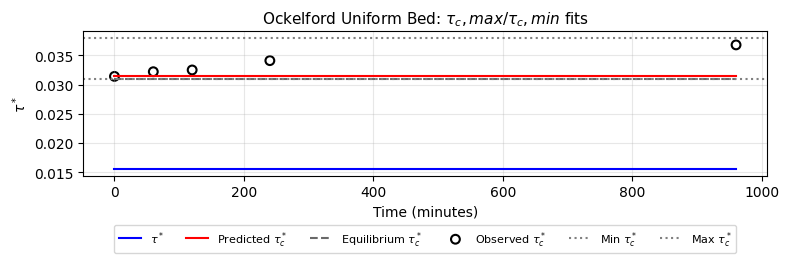

MAE between predicted and observed τ*c: 0.00200


In [55]:
tauc_obs_uniform = tauc_measurements_flume['uniform'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.031
tauc_max = 0.038

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['uniform'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0049,
    B=6.6528,
    ks=51.227,
    kw=11.99
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['uniform'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Uniform Bed: $\tau_c,max$/$\tau_c,min$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

b) From $D84/D50$ fits: 

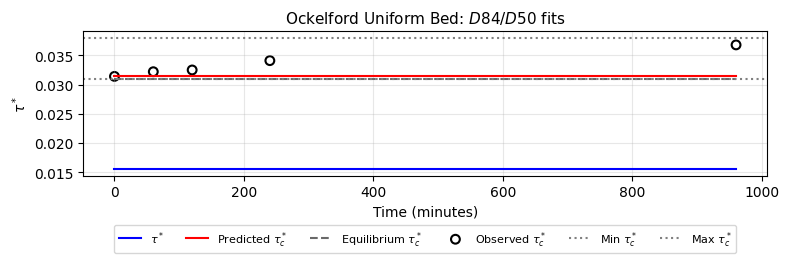

MAE between predicted and observed τ*c: 0.00200


In [56]:
tauc_obs_uniform = tauc_measurements_flume['uniform'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.031
tauc_max = 0.038

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['uniform'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0649,
    B=10.018,
    ks=68.358,
    kw=12.022
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['uniform'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Uniform Bed: $D84/D50$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

c) From $\sqrt{D84/D16}$

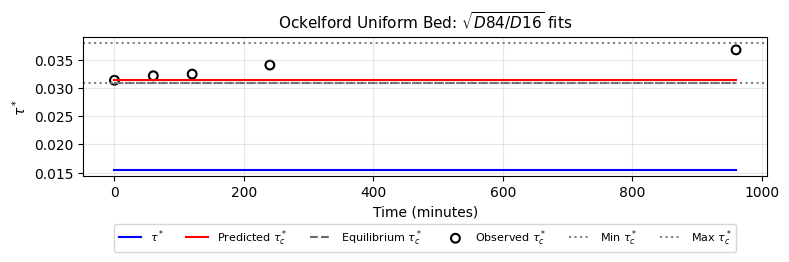

MAE between predicted and observed τ*c: 0.00200


In [57]:
tauc_obs_uniform = tauc_measurements_flume['uniform'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.031
tauc_max = 0.038

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['uniform'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0136,
    B=9.7147,
    ks=66.735,
    kw=12.022
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['uniform'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Uniform Bed: $\sqrt{D84/D16}$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

### Bimodal Bed

a) From $\tau_cmax^* / \tau_cmin^*$ fits: 

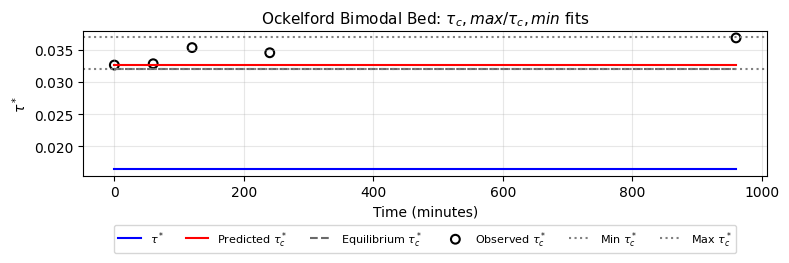

MAE between predicted and observed τ*c: 0.00180


In [58]:
tauc_obs_uniform = tauc_measurements_flume['bimodal'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.032
tauc_max = 0.037

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['bimodal'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0052,
    B=6.8362,
    ks=51.935,
    kw=12.128
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['bimodal'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Bimodal Bed: $\tau_c,max$/$\tau_c,min$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

b) From $D84/D50$ fits: 

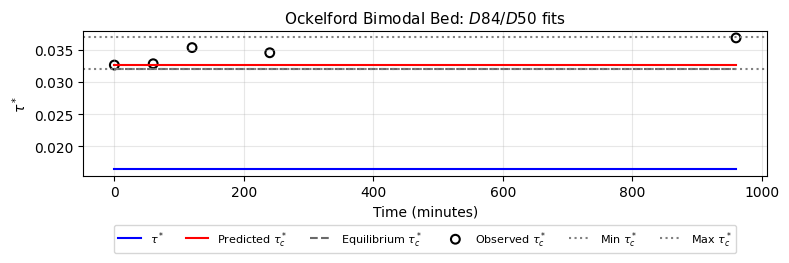

MAE between predicted and observed τ*c: 0.00180


In [59]:
tauc_obs_uniform = tauc_measurements_flume['bimodal'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.032
tauc_max = 0.037

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['bimodal'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0092,
    B=6.7809,
    ks=51.119,
    kw=10.826
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['bimodal'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Bimodal Bed: $D84/D50$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

c) From $\sqrt{D84/D16}$

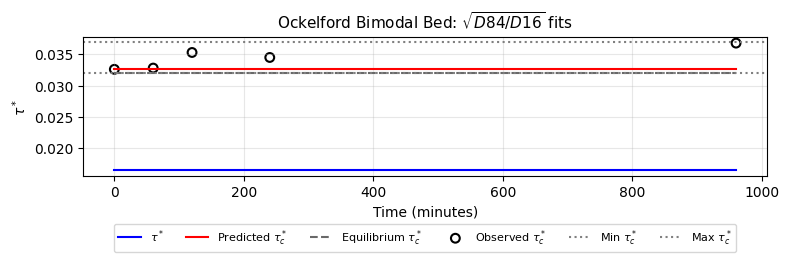

MAE between predicted and observed τ*c: 0.00180


In [60]:
tauc_obs_uniform = tauc_measurements_flume['bimodal'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.032
tauc_max = 0.037

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['bimodal'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0092,
    B=6.7809,
    ks=51.119,
    kw=10.826
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['bimodal'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Bimodal Bed: $\sqrt{D84/D16}$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

### Unimodal Bed

a) From $\tau_cmax^* / \tau_cmin^*$ fits: 

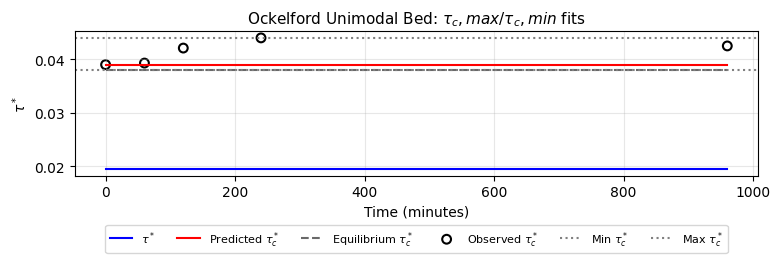

MAE between predicted and observed τ*c: 0.00238


In [61]:
tauc_obs_uniform = tauc_measurements_flume['unimodal'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.038
tauc_max = 0.044

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['unimodal'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0053,
    B=6.8713,
    ks=52.061,
    kw=12.151
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['unimodal'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Unimodal Bed: $\tau_c,max$/$\tau_c,min$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

b) From $D84/D50$ fits: 

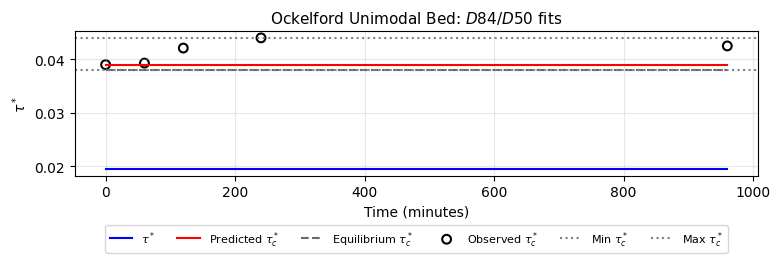

MAE between predicted and observed τ*c: 0.00238


In [62]:
tauc_obs_uniform = tauc_measurements_flume['unimodal'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.038
tauc_max = 0.044

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['unimodal'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0092,
    B=6.7809,
    ks=51.119,
    kw=10.826
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['unimodal'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Unimodal Bed: $D84/D50$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

c) From $\sqrt{D84/D16}$

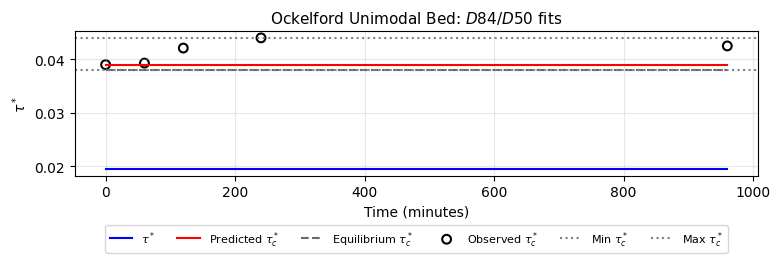

MAE between predicted and observed τ*c: 0.00238


In [63]:
tauc_obs_uniform = tauc_measurements_flume['unimodal'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.038
tauc_max = 0.044

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['unimodal'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0072,
    B=6.7809,
    ks=51.119,
    kw=10.826
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['unimodal'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Unimodal Bed: $D84/D50$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')

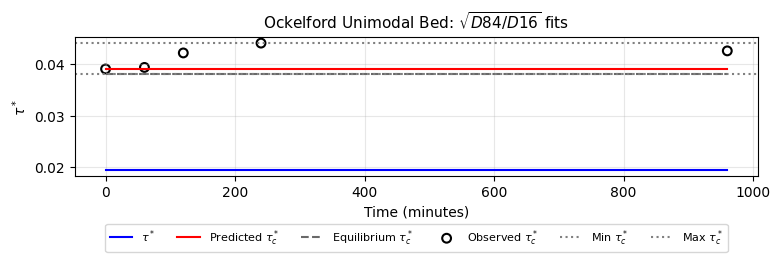

MAE between predicted and observed τ*c: 0.00238


In [64]:
tauc_obs_uniform = tauc_measurements_flume['unimodal'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = 0.038
tauc_max = 0.044

tauc_flume_uniform, k_flume_uniform, tau_pot_flume_uniform, ratio_uniform = evolve_tauc_tc(
    tau_star_flume['unimodal'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_uniform,
    A=0.0072,
    B=7.0789,
    ks=53.773,
    kw=8.2429
)
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_uniform, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['unimodal'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_uniform, index=tauc_measurements_flume.index)

# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_uniform, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')
# plot min and max observed τ*c as horizontal lines
ax.axhline(tauc_min, linestyle=':', color='grey', label=r'Min $\tau_c^*$')
ax.axhline(tauc_max, linestyle=':', color='grey', label=r'Max $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=10)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=6)
ax.grid(True, alpha=0.3)

plt.title(r'Ockelford Unimodal Bed: $\sqrt{D84/D16}$ fits', fontsize=11)
plt.tight_layout()
plt.show()

# calculate MAE between measured and predicted τ*c at observation points
pred_at_obs = tau_c_pred_series[obs_tauc_series.index]
mae = mean_absolute_error(obs_tauc_series.values, pred_at_obs.values)
print(f'MAE between predicted and observed τ*c: {mae:.5f}')